In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

def gaussian_smooth_by_nt(x, y, sigma_nt, truncate=4.0):
    x = np.asarray(x)
    y = np.asarray(y)
    if x.ndim != 1 or y.ndim != 1 or x.size != y.size:
        raise ValueError("x and y must be 1D arrays of the same length")
    dx = np.median(np.diff(x))
    if dx <= 0:
        raise ValueError("x must be strictly increasing")
    sigma_idx = sigma_nt / dx
    y_smooth = gaussian_filter1d(y, sigma=sigma_idx, mode="nearest", truncate=truncate)
    return x, y_smooth

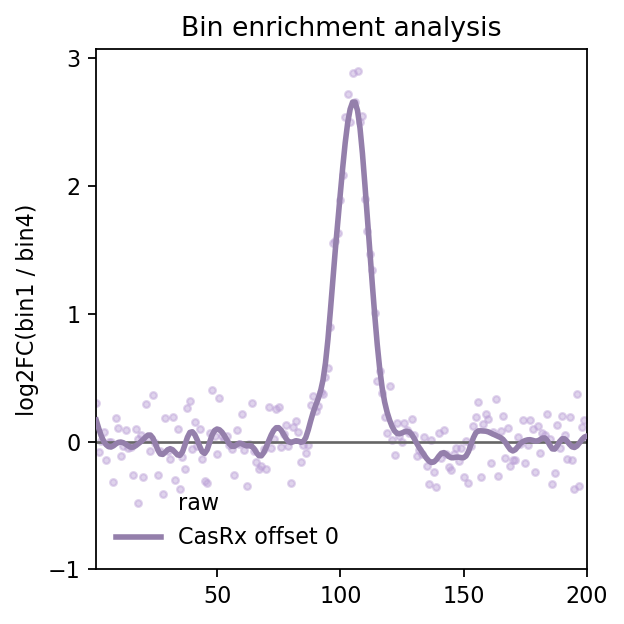

In [3]:
np.random.seed(7)

x = np.arange(1, 201)
noise = np.random.normal(0, 0.18, size=200)
peak = 2.8 * np.exp(-0.5 * ((x - 105) / 6) ** 2)
y = noise + peak

sigma_nt_default = 2
x_s, y_s = gaussian_smooth_by_nt(x, y, sigma_nt_default)

offset = 0
line_sh = "#947fab"

fig, ax = plt.subplots(figsize=(4, 4), dpi=160)

ax.plot(x, y, "o", ms=3, alpha=0.45, color="#ba9fd6", label="raw")
ax.plot(x_s, y_s, color=line_sh, linewidth=2.5, zorder=3, label=f"CasRx offset {offset}")

# ax.axhspan(-0.02, 0.02, color="#666666", alpha=0.6, zorder=0)
ax.axhline(0, color="#666666", linewidth=1.2, zorder=2)
ax.margins(x=0)
ax.set_xticks([50, 100, 150, 200])
ax.set_yticks([-1, 0, 1, 2, 3])
ax.set_ylabel("log2FC(bin1 / bin4)")
ax.set_title("Bin enrichment analysis")
ax.legend(frameon=False)

# output_dir = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Figure5_Graph/Reviewed_Figure5/260728_Dummy"
# os.makedirs(output_dir, exist_ok=True)
# pdf_path = os.path.join(output_dir, "260728_figure5_Dummydata.pdf")
# plt.savefig(pdf_path, format="pdf", bbox_inches="tight")

plt.tight_layout()
plt.show()